# Baseline noise correlations (session level)
Within-region pairwise spike-count correlations in the pre-stimulus window, trial-balanced per condition. No condition normalization (no stimulus signal pre-stim). Per-pair firing rates are saved, plus a firing-rate-corrected r_SC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, hashlib
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_dir = prefix + 'neural/'

# ---- parameters ----
BASELINE = (-0.2, 0.0)        # pre-stimulus window (s)
PAIR_SCOPE = 'within_region'  # currently only within-region pairs are formed
BALANCE_BY_CONDITION = True   # equalize #trials per condition within each session
CORRECT_ONLY = False          # restrict to correct trials (baseline precedes outcome)
MIN_RATE = 0.5                # Hz; drop near-silent neurons (low rates attenuate r_SC)
MIN_TRIALS = 50               # skip sessions with fewer usable (balanced) trials
MIN_NEURONS = 5               # need >=5 neurons in a region to form pairs
SEED = 0

# Region filter applied to neurons (same convention as the other scripts):
#   None -> keep all ; 'drop_root' -> drop unlocalized ; or a list of acronyms
REGION_FILTER = 'drop_root'

def area_mask(area_series):
    if REGION_FILTER is None:
        return np.ones(len(area_series), dtype=bool)
    if REGION_FILTER == 'drop_root':
        return (area_series != 'root').values
    return area_series.isin(REGION_FILTER).values

# correct-trial lookup (only used if CORRECT_ONLY)
correct_by_session = {}
if CORRECT_ONLY:
    tdf = pd.read_parquet(trials_path)
    correct_by_session = (tdf[tdf['correct'] == 1.0]
                          .groupby('session')['trial_id'].apply(set).to_dict())

def session_seed(s):
    return (int(hashlib.md5(s.encode()).hexdigest()[:8], 16) + SEED) % (2**32)

print("params set; REGION_FILTER =", REGION_FILTER)

params set; REGION_FILTER = drop_root


## Load single-trial baseline rates (per session)

In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])

# baseline columns (t_ labelled in seconds)
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
bcols = [c for c, m in zip(tcols, (tsec >= BASELINE[0]) & (tsec <= BASELINE[1])) if m]
print(f"Baseline window {BASELINE}: {len(bcols)} of {len(tcols)} bins")

# session -> list of (trials x neurons baseline-rate pivot, area map); + trial->condition
sess_pivots = defaultdict(list)
sess_cond = {}

for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[area_mask(d['area'])]
        if len(d) == 0:
            continue
        session = d['session'].iloc[0]
        d = d.copy()
        d['rate'] = np.nanmean(d[bcols].values, axis=1)               # per-trial baseline rate
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        piv = d.pivot_table(index='trial_id', columns='nuid', values='rate')
        amap = d.groupby('nuid')['area'].first()
        sess_pivots[session].append((piv, amap))
        if session not in sess_cond:
            sess_cond[session] = d.drop_duplicates('trial_id').set_index('trial_id')['condition']
        if (i + 1) % 100 == 0:
            print(f"  loaded {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

print(f"Sessions with data: {len(sess_pivots)}")

Baseline window (-0.2, 0.0): 12 of 90 bins
  loaded 100/380 files...
  loaded 200/380 files...
  loaded 300/380 files...
Sessions with data: 244


## Compute within-region pairwise noise correlations

In [4]:
def balance_trials(cond, seed):
    """cond: Series trial_id -> condition (restricted to available trials).
    Returns chosen trial_ids with equal count per condition (min across conditions)."""
    rng = np.random.default_rng(seed)
    cond = cond.dropna()
    counts = cond.value_counts()
    n = int(counts.min())
    chosen = []
    for c, sub in cond.groupby(cond):
        ids = sub.index.values
        chosen.extend(rng.choice(ids, size=n, replace=False))
    return np.array(chosen), n

pair_session, pair_area = [], []
pair_r, pair_geo, pair_ri, pair_rj = [], [], [], []
session_info = []   # session, n_neurons_used, n_trials_used, mean_rate

for session, parts in sess_pivots.items():
    X = pd.concat([p for p, _ in parts], axis=1)          # trials x neurons (aligned on trial_id)
    areas = pd.concat([a for _, a in parts])
    areas = areas[~areas.index.duplicated()]

    # ---- choose trials ----
    cond = sess_cond[session].reindex(X.index)
    if CORRECT_ONLY:
        ok = correct_by_session.get(session, set())
        cond = cond[cond.index.isin(ok)]
        X = X.loc[cond.index]
    if BALANCE_BY_CONDITION and cond.notna().any():
        chosen, n_per = balance_trials(cond, session_seed(session))
        X = X.loc[chosen]
    X = X.dropna(axis=0, how='any')                       # keep trials present for all neurons

    # ---- QC neurons on the chosen trials ----
    rates = X.mean(axis=0)
    keep = (rates >= MIN_RATE) & (X.std(axis=0) > 0)
    X = X.loc[:, keep.values]
    areas = areas.reindex(X.columns)

    if X.shape[0] < MIN_TRIALS or X.shape[1] < MIN_NEURONS:
        continue
    session_info.append(dict(session=session, n_neurons=X.shape[1],
                             n_trials=X.shape[0], mean_rate=float(X.values.mean())))

    # ---- within-region pairwise Pearson ----
    for region, neurons in areas.groupby(areas):
        cols = neurons.index
        if len(cols) < 2:
            continue
        sub = X[cols].values                              # trials x neurons
        C = np.corrcoef(sub, rowvar=False)
        rate_vec = sub.mean(axis=0)
        iu, ju = np.triu_indices(len(cols), k=1)
        rr = C[iu, ju]
        ri, rj = rate_vec[iu], rate_vec[ju]
        pair_session.append(np.repeat(session, len(rr)))
        pair_area.append(np.repeat(region, len(rr)))
        pair_r.append(rr); pair_geo.append(np.sqrt(ri * rj))
        pair_ri.append(ri); pair_rj.append(rj)

pairs = pd.DataFrame({
    'session': np.concatenate(pair_session),
    'area': np.concatenate(pair_area),
    'rSC': np.concatenate(pair_r),
    'geo_rate': np.concatenate(pair_geo),
    'rate_i': np.concatenate(pair_ri),
    'rate_j': np.concatenate(pair_rj),
}).dropna(subset=['rSC'])

info_df = pd.DataFrame(session_info)
print(f"Pairs: {len(pairs):,} | sessions: {pairs['session'].nunique()} | "
      f"mean r_SC = {pairs['rSC'].mean():.4f}")

Pairs: 521,040 | sessions: 227 | mean r_SC = 0.0472


## Firing-rate correction + session-level aggregation

In [5]:
# Regress out pair firing rate: r_SC ~ log(geo-mean rate); keep residual + global mean
m = pairs['geo_rate'] > 0
b = np.polyfit(np.log(pairs.loc[m, 'geo_rate']), pairs.loc[m, 'rSC'], 1)
pred = np.polyval(b, np.log(pairs['geo_rate']))
global_mean = pairs['rSC'].mean()
pairs['rSC_corrected'] = pairs['rSC'] - pred + global_mean
print(f"rate-correction slope (rSC per log-Hz): {b[0]:+.4f}")

session_df = (pairs.groupby('session')
              .agg(mean_rSC=('rSC', 'mean'),
                   rSC_rate_corrected=('rSC_corrected', 'mean'),
                   n_pairs=('rSC', 'size'),
                   pair_geo_rate=('geo_rate', 'mean'))
              .reset_index()
              .merge(info_df, on='session', how='left'))

# save
pairs.to_parquet(out_dir + 'noise_corr_pairs_baseline.parquet')
session_df.to_parquet(out_dir + 'noise_corr_session_baseline.parquet')
print(f"saved {len(pairs):,} pairs and {len(session_df)} sessions")
print(session_df[['session','mean_rSC','rSC_rate_corrected','n_neurons','n_trials','mean_rate']].head())

rate-correction slope (rSC per log-Hz): +0.0019
saved 521,040 pairs and 227 sessions
                                session  mean_rSC  rSC_rate_corrected  \
0  032452e9-1886-449d-9c13-0f192572e19f  0.115279            0.116385   
1  034e726f-b35f-41e0-8d6c-a22cc32391fb  0.095263            0.095324   
2  09156021-9a1d-4e1d-ae59-48cbde3c5d42  0.030682            0.031421   
3  09394481-8dd2-4d5c-9327-f2753ede92d7  0.026487            0.025689   
4  09b2c4d1-058d-4c84-9fd4-97530f85baf6  0.039458            0.039861   

   n_neurons  n_trials  mean_rate  
0         30       190   4.708772  
1        122       140   9.141393  
2         75       180   5.701111  
3        203       200  22.892488  
4        220       150  12.683333  


## Plots

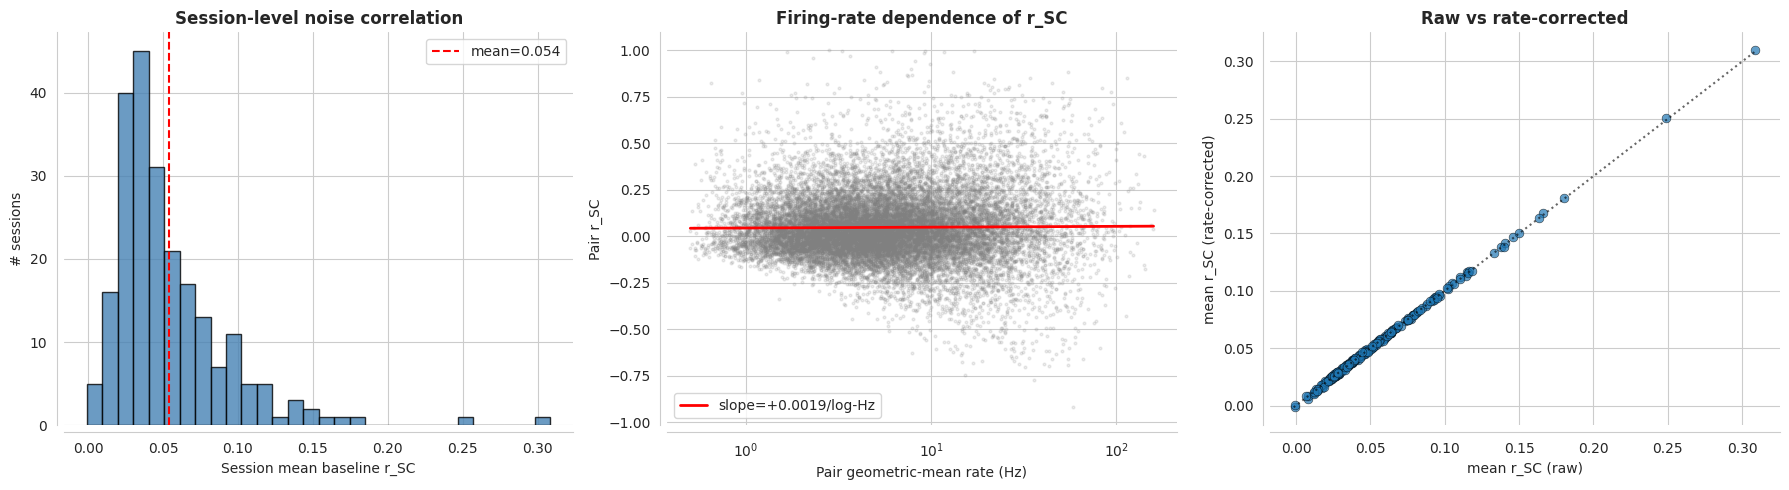

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) distribution of session mean r_SC
axes[0].hist(session_df['mean_rSC'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(session_df['mean_rSC'].mean(), color='red', ls='--',
                label=f"mean={session_df['mean_rSC'].mean():.3f}")
axes[0].set_xlabel('Session mean baseline r_SC'); axes[0].set_ylabel('# sessions')
axes[0].set_title('Session-level noise correlation', fontweight='bold'); axes[0].legend()

# (2) rate-correction diagnostic: pair r_SC vs geo-mean rate (subsample for speed)
samp = pairs.sample(min(20000, len(pairs)), random_state=0)
axes[1].scatter(samp['geo_rate'], samp['rSC'], s=4, alpha=0.15, color='gray')
xs = np.linspace(samp['geo_rate'].min(), samp['geo_rate'].max(), 100)
axes[1].plot(xs, np.polyval(b, np.log(np.clip(xs, 1e-3, None))), 'r-', lw=2,
             label=f'slope={b[0]:+.4f}/log-Hz')
axes[1].set_xlabel('Pair geometric-mean rate (Hz)'); axes[1].set_ylabel('Pair r_SC')
axes[1].set_title('Firing-rate dependence of r_SC', fontweight='bold'); axes[1].legend()
axes[1].set_xscale('log')

# (3) raw vs rate-corrected session r_SC
axes[2].scatter(session_df['mean_rSC'], session_df['rSC_rate_corrected'],
                s=40, alpha=0.7, edgecolors='black', linewidth=0.4)
lims = [min(session_df['mean_rSC'].min(), session_df['rSC_rate_corrected'].min()),
        max(session_df['mean_rSC'].max(), session_df['rSC_rate_corrected'].max())]
axes[2].plot(lims, lims, 'k:', alpha=0.6)
axes[2].set_xlabel('mean r_SC (raw)'); axes[2].set_ylabel('mean r_SC (rate-corrected)')
axes[2].set_title('Raw vs rate-corrected', fontweight='bold')

for ax in axes:
    sns.despine(ax=ax, offset=5)
plt.tight_layout(); plt.show()

## Noise correlation vs LDA 1

In [7]:
# Merge session-level noise correlation with LDA 1
from scipy.stats import pearsonr, spearmanr

lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
nc = session_df.merge(lda[['session', 'lda_1']], on='session', how='inner').dropna(subset=['mean_rSC', 'lda_1'])

def partial_corr(x, y, z):
    """Pearson corr of x,y after linearly removing z from both."""
    x, y, z = map(lambda v: np.asarray(v, float), (x, y, z))
    Z = np.c_[np.ones_like(z), z]
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return pearsonr(rx, ry)

print(f"n sessions = {len(nc)}\n")
for col, label in [('mean_rSC', 'raw r_SC'), ('rSC_rate_corrected', 'rate-corrected r_SC')]:
    r, p = pearsonr(nc[col], nc['lda_1'])
    rho, pp = spearmanr(nc[col], nc['lda_1'])
    pr, ppr = partial_corr(nc[col], nc['lda_1'], nc['mean_rate'])
    print(f"{label} vs LDA 1:")
    print(f"   pearson  r={r:+.3f} p={p:.3f} | spearman rho={rho:+.3f} p={pp:.3f}")
    print(f"   partial (control mean_rate) r={pr:+.3f} p={ppr:.3f}\n")

n sessions = 227

raw r_SC vs LDA 1:
   pearson  r=+0.017 p=0.800 | spearman rho=-0.039 p=0.563
   partial (control mean_rate) r=+0.027 p=0.688

rate-corrected r_SC vs LDA 1:
   pearson  r=+0.016 p=0.805 | spearman rho=-0.040 p=0.554
   partial (control mean_rate) r=+0.028 p=0.678



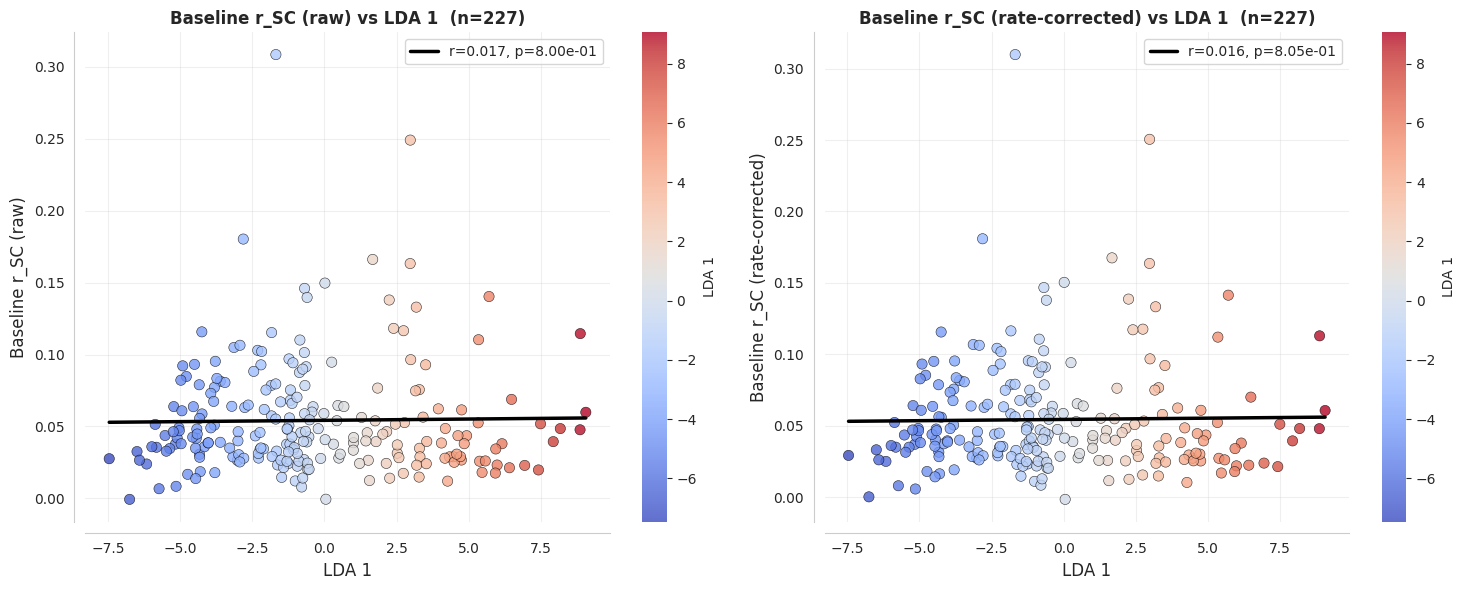

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, label in [(axes[0], 'mean_rSC', 'Baseline r_SC (raw)'),
                       (axes[1], 'rSC_rate_corrected', 'Baseline r_SC (rate-corrected)')]:
    x = nc['lda_1'].values
    y = nc[col].values
    r, p = pearsonr(y, x)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=55,
                    edgecolors='black', linewidth=0.4)
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
    cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1', fontsize=10); cb.outline.set_visible(False)
    ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} vs LDA 1  (n={len(nc)})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    sns.despine(ax=ax, offset=8)

plt.tight_layout(); plt.show()

## Single-region noise correlation vs LDA 1

In [9]:
# ---- Single-region noise correlation vs LDA 1 ----
# Pick a region well represented across sessions (spanning the LDA-1 axis).
TARGET_REGION = 'CA1'   # e.g. CA1, DG, CP, MRN, CA3, LP, PO, ZI
MIN_PAIRS = 10          # require this many within-region pairs in a session

# region representation overview (sessions present + LDA span)
_reg = pairs.groupby(['session', 'area'], as_index=False).agg(
    rSC=('rSC', 'mean'), rSC_corr=('rSC_corrected', 'mean'),
    geo_rate=('geo_rate', 'mean'), n_pairs=('rSC', 'size'))
_reg = _reg.merge(lda[['session', 'lda_1']], on='session')
overview = (_reg.groupby('area').agg(n_sessions=('session', 'nunique'),
            lda_min=('lda_1', 'min'), lda_max=('lda_1', 'max'))
            .sort_values('n_sessions', ascending=False))
print("Best-represented regions:\n", overview.head(8), "\n")

# region-level session table
rdf = _reg[(_reg['area'] == TARGET_REGION) & (_reg['n_pairs'] >= MIN_PAIRS)].dropna(subset=['rSC', 'lda_1'])

for col, label in [('rSC', 'raw r_SC'), ('rSC_corr', 'rate-corrected r_SC')]:
    r, p = pearsonr(rdf[col], rdf['lda_1'])
    rho, pp = spearmanr(rdf[col], rdf['lda_1'])
    pr, ppr = partial_corr(rdf[col], rdf['lda_1'], rdf['geo_rate'])
    print(f"[{TARGET_REGION}] {label} vs LDA1 (n={len(rdf)}): "
          f"pearson r={r:+.3f} p={p:.3f} | spearman rho={rho:+.3f} p={pp:.3f} | "
          f"partial(rate) r={pr:+.3f} p={ppr:.3f}")

Best-represented regions:
       n_sessions   lda_min   lda_max
area                                
CA1           51 -5.863881  8.858734
DG            43 -5.863881  8.858734
CP            42 -7.456990  9.058085
MRN           39 -6.494203  9.058085
CA3           35 -5.821165  8.174856
LP            33 -5.729917  8.858734
PO            25 -5.821165  7.929832
ZI            24 -5.359796  8.174856 

[CA1] raw r_SC vs LDA1 (n=38): pearson r=-0.058 p=0.730 | spearman rho=-0.078 p=0.642 | partial(rate) r=-0.139 p=0.405
[CA1] rate-corrected r_SC vs LDA1 (n=38): pearson r=-0.063 p=0.706 | spearman rho=-0.104 p=0.536 | partial(rate) r=-0.140 p=0.402


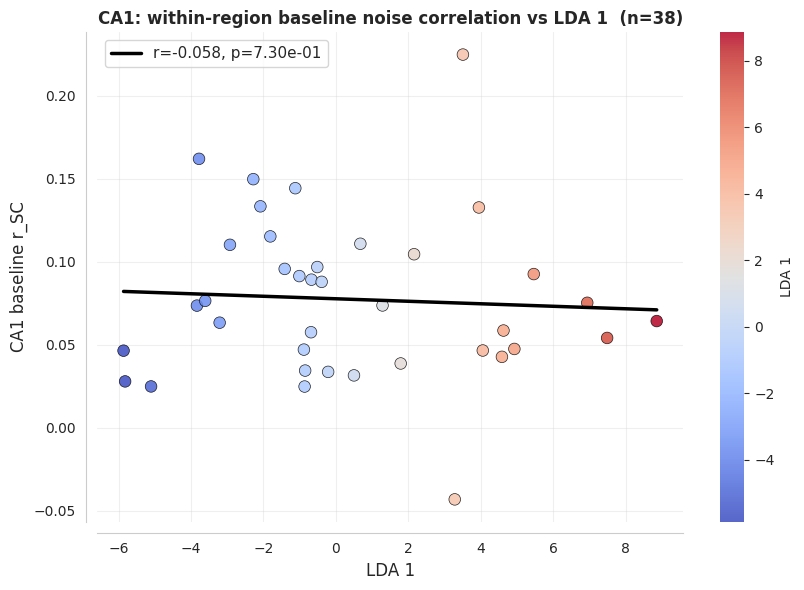

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 6))
x = rdf['lda_1'].values; y = rdf['rSC'].values
r, p = pearsonr(y, x)
sc = ax.scatter(x, y, c=x, cmap='coolwarm', s=70, alpha=0.85, edgecolors='black', linewidth=0.5)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(f'{TARGET_REGION} baseline r_SC', fontsize=12)
ax.set_title(f'{TARGET_REGION}: within-region baseline noise correlation vs LDA 1  (n={len(rdf)})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
sns.despine(ax=ax, offset=8)
plt.tight_layout(); plt.show()

## Region scan: r_SC vs LDA 1 across regions

In [11]:
# ---- Scan: within-region r_SC vs LDA 1 across all well-sampled regions ----
MIN_SESSIONS_SCAN = 15   # only test regions present in >= this many sessions
MIN_PAIRS = 10

base = _reg[_reg['n_pairs'] >= MIN_PAIRS].dropna(subset=['rSC', 'lda_1'])

rows = []
for region, g in base.groupby('area'):
    if g['session'].nunique() < MIN_SESSIONS_SCAN:
        continue
    n = len(g)
    r, p = pearsonr(g['rSC'], g['lda_1'])
    rho, pp = spearmanr(g['rSC'], g['lda_1'])
    pr, ppr = partial_corr(g['rSC'], g['lda_1'], g['geo_rate'])
    # Fisher-z 95% CI for Pearson r
    zse = 1.0 / np.sqrt(n - 3)
    lo, hi = np.tanh(np.arctanh(r) - 1.96 * zse), np.tanh(np.arctanh(r) + 1.96 * zse)
    rows.append(dict(region=region, n=n, pearson_r=r, p=p, ci_lo=lo, ci_hi=hi,
                     spearman_rho=rho, p_spear=pp, partial_r=pr, p_partial=ppr))

scan = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print(scan.to_string(index=False))
print(f"\nRegions tested: {len(scan)} (Bonferroni alpha = {0.05/len(scan):.4f})")

region  n  pearson_r     p  ci_lo  ci_hi  spearman_rho  p_spear  partial_r  p_partial
    CP 39      0.198 0.227 -0.126  0.483         0.149    0.365      0.183      0.265
   CA1 38     -0.058 0.730 -0.371  0.267        -0.078    0.642     -0.139      0.405
   MRN 35      0.165 0.343 -0.178  0.472         0.194    0.264      0.163      0.350
    LP 28      0.028 0.889 -0.349  0.397         0.024    0.905      0.019      0.922
    DG 26     -0.100 0.628 -0.469  0.299        -0.015    0.943     -0.086      0.677
    PO 22      0.147 0.515 -0.293  0.535         0.315    0.154      0.083      0.715
   CA3 22      0.033 0.884 -0.394  0.448         0.109    0.629     -0.024      0.914
   MOs 20      0.252 0.285 -0.215  0.625         0.185    0.435      0.196      0.407
   APN 20     -0.146 0.539 -0.553  0.317        -0.105    0.659     -0.143      0.549
   MOp 20     -0.362 0.116 -0.694  0.095        -0.278    0.235     -0.361      0.117
   IRN 16      0.356 0.175 -0.169  0.724         0.324

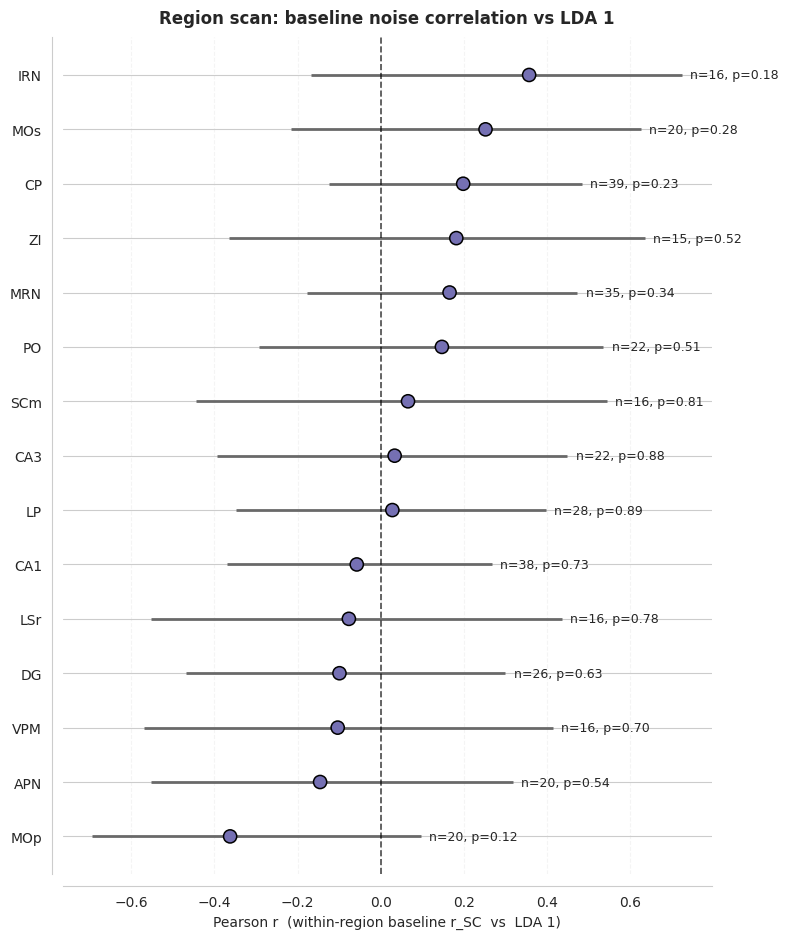

In [12]:
# Forest plot: Pearson r (within-region r_SC vs LDA1) per region, 95% CI
d = scan.sort_values('pearson_r').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 0.5 * len(d) + 2))
y = np.arange(len(d))
colors = ['#d95f02' if p < 0.05 else '#7570b3' for p in d['p']]
ax.hlines(y, d['ci_lo'], d['ci_hi'], color='dimgray', lw=2, zorder=1)
ax.scatter(d['pearson_r'], y, c=colors, s=90, edgecolors='black', lw=1.1, zorder=2)
ax.axvline(0, color='black', ls='--', lw=1.2, alpha=0.7)
for i, row in d.iterrows():
    ax.text(row['ci_hi'] + 0.02, i, f"n={int(row['n'])}, p={row['p']:.2f}",
            va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(d['region'])
ax.set_xlabel('Pearson r  (within-region baseline r_SC  vs  LDA 1)')
ax.set_title('Region scan: baseline noise correlation vs LDA 1', fontweight='bold', pad=10)
ax.grid(True, axis='x', alpha=0.2, ls='--')
sns.despine(ax=ax, offset=8)
plt.tight_layout(); plt.show()